<div style="background-color:#5A3516; color:#F3EEE6; padding:22px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h1 style="color:#F3EEE6; margin-bottom:0;"><b>Machine Learning II — Customer Segmentation</b></h1>
<h3 style="color:#D8C0B4; margin-top:6px;">Notebook 4 — Cluster Characterization</h3>
<p style="color:#D8C0B4; font-size:15px; margin-top:14px;">This notebook translates the final numerical cluster labels into interpretable customer segments using spend, behavioural, demographic, complaint and geographic profiles.</p>
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:18px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin-top:0;"><b>Index</b></h2>
<ol>
<li>Imports and data loading</li>
<li>Segment sizes</li>
<li>Spend profile</li>
<li>Behavioural and demographic profile</li>
<li>Loyalty, gender and household checks</li>
<li>Normalised comparison</li>
<li>Radar profile summary</li>
<li>Feature by feature plots</li>
<li>Main differentiators by cluster</li>
<li>Cluster interpretation and naming rationale</li>
<li>Geographic check</li>
<li>Final segment names</li>
<li>Export ID and cluster mapping</li>
</ol>
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1) Imports and data loading</b></h2>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Characterization logic.</b><br><br>
This notebook does not change the clusters created in the modelling stage. Its purpose is to translate the numerical labels into meaningful customer groups. For that reason, every name is based on repeated evidence across spend, promotion behaviour, demographics, loyalty and service indicators.
</div>

In [6]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils_cluster_characterization as ucc

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_DIR = Path("../datasets")
df = ucc.load_characterization_data(DATA_DIR)
print("Characterization dataset shape:", df.shape)
df.head()

PROJECT_PALETTE = ['#B87540', '#B2543D', '#7E6A43', '#A8B7BA', '#D8C0B4', '#C8AB8C', '#5A3516', '#B98F70']
sns.set_theme(style='whitegrid', palette=PROJECT_PALETTE)

Characterization dataset shape: (33038, 29)


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2) Segment sizes</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The first check is the size of each segment. Very small clusters would require caution because they may represent niche behaviour or residual outlier structure rather than stable customer segments.</p>
</div>

,cluster,cluster_name,customers,share_%
0,0,Loyalists,3394,10.3
1,1,Vegetarians,3740,11.3
2,2,Regulars,6364,19.3
3,3,Promoters,4295,13.0
4,4,Wellness,3323,10.1
5,5,Families,3663,11.1
6,6,Economizers,5061,15.3
7,7,Techies,3198,9.7


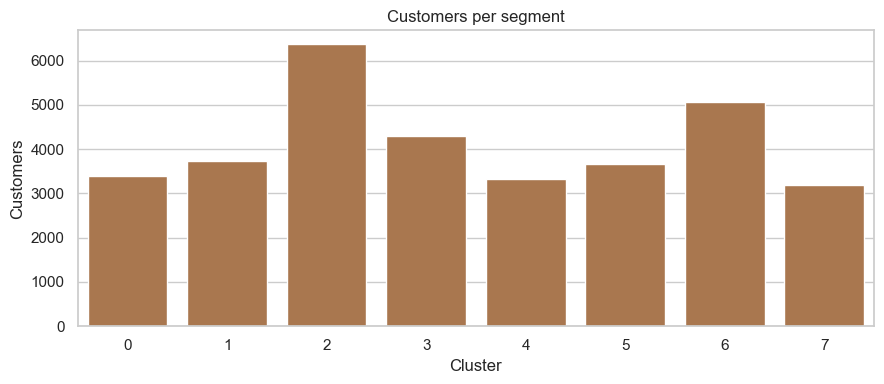

In [7]:
size_profile = ucc.cluster_sizes(df)
display(size_profile)
ucc.plot_cluster_sizes(size_profile)


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>3) Spend profile</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">Absolute lifetime spend by category is used to understand the main purchasing orientation of each segment. These variables are kept in original units for interpretability.</p>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why absolute spend is still useful here.</b><br><br>
The clustering model avoids giving too much weight to dominant variables, but the interpretation stage should still look at the real spending levels. Absolute spend helps identify whether a segment is commercially relevant, while the normalised comparison later shows which categories are most distinctive within each group.
</div>

,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_spend_technology
cluster,,,,,,,,,
0,29398.77,334.85,716.27,708.39,1012.70,1000.67,1290.31,366.98,3464.04
1,10693.80,2007.23,418.01,413.08,74.53,88.95,714.51,261.28,2251.99
2,17926.74,521.23,339.15,362.19,794.98,679.57,752.91,396.15,1479.46
3,12883.59,404.22,242.06,414.13,718.24,419.91,480.31,304.55,1321.31
4,12216.14,1508.72,611.55,167.75,162.17,117.63,2017.15,415.24,982.42
5,25353.74,804.78,820.37,1502.16,1494.31,1332.58,920.18,361.82,5346.57
6,12768.35,355.08,259.51,581.10,614.14,434.95,458.39,273.66,1381.64
7,9832.56,181.38,562.33,1099.42,916.80,863.33,252.12,302.43,12070.23
OVERALL,16306.23,727.50,464.35,622.00,723.79,608.14,820.44,336.26,3139.17


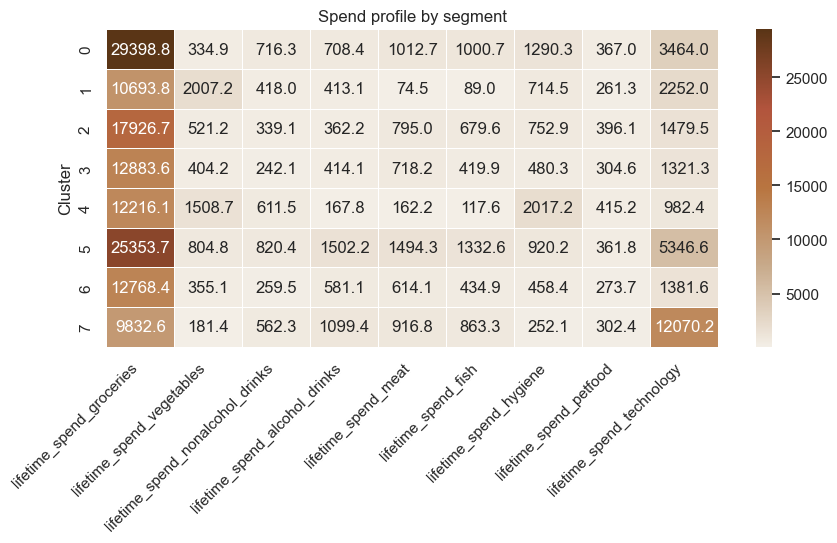

In [8]:
spend_cols = ucc.spend_columns(df)
spend_profile = ucc.profile_table(df, spend_cols)
display(spend_profile)
ucc.plot_profile_heatmap(spend_profile, "Spend profile by segment")

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>4) Behavioural and demographic profile</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">This table adds non spend variables such as promotion usage, product diversity, age, education, tenure, children and complaints. These variables are not all used to fit the clustering model, but they are essential to understand who the customers are and to assign defensible business names to the final segments.</p>
</div>

,log_total_spend,percentage_of_products_bought_promotion,distinct_stores_visited,lifetime_total_distinct_products,customer_age,education_level,tenure,total_children,number_complaints,customer_loyalty_flag,is_male
cluster,,,,,,,,,,,
0,10.42,0.50,3.94,238.42,58.02,15.43,13.49,1.98,1.10,0.77,0.50
1,9.66,0.11,3.20,83.95,57.14,15.96,11.46,1.92,0.78,0.58,0.51
2,9.95,0.17,2.54,153.36,56.00,15.08,12.02,1.59,0.75,0.63,0.49
3,9.62,0.86,3.71,93.96,50.11,13.92,9.93,1.44,1.03,0.64,0.48
4,9.76,0.17,3.57,121.69,56.67,16.24,9.71,1.89,0.57,0.59,0.50
5,10.50,0.21,3.26,294.42,56.89,15.48,13.13,5.35,0.93,0.68,0.52
6,9.65,0.47,3.65,112.90,48.35,13.93,9.23,1.54,1.11,0.48,0.50
7,10.12,0.26,1.52,113.49,56.13,12.26,9.08,0.64,1.06,0.49,0.47
OVERALL,9.93,0.35,3.17,148.91,54.58,14.78,11.01,1.99,0.91,0.60,0.50


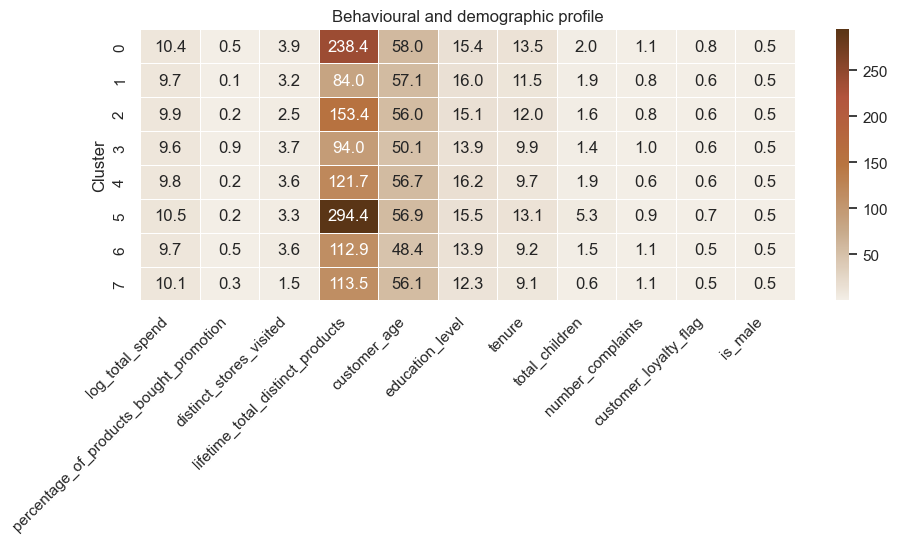

In [9]:
profile_cols = ucc.behavioural_profile_columns(df)
behaviour_profile = ucc.profile_table(df, profile_cols)
display(behaviour_profile)
ucc.plot_profile_heatmap(behaviour_profile, "Behavioural and demographic profile")

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>5) Loyalty, gender and household checks</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0;">These plots check whether the final clusters also differ in simple customer attributes that were useful in previous segmentation work.</p>
</div>

/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/clustering/utils_cluster_characterization.py:231: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=summary, x=cluster_col, y="share_%", hue="feature", palette=[MAIN_COLOR, SECONDARY_COLOR, NOTE_COLOR])


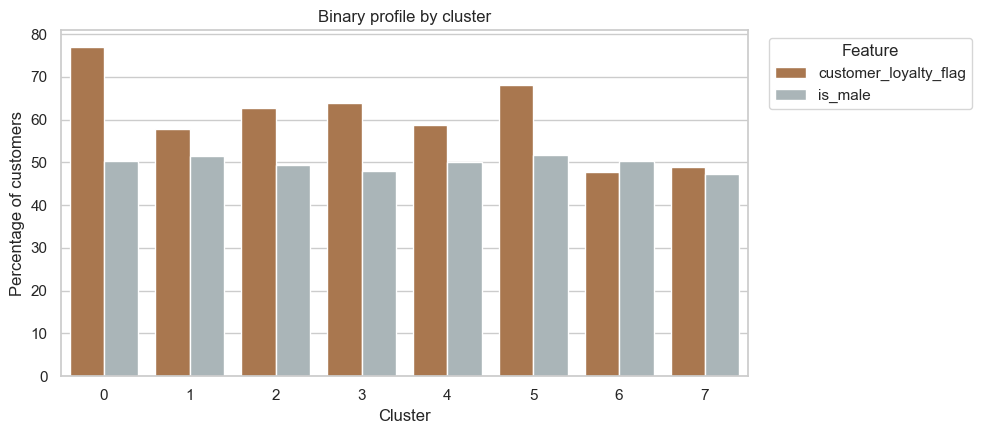

,cluster,feature,share_%
0,0,customer_loyalty_flag,77.0
1,1,customer_loyalty_flag,57.8
2,2,customer_loyalty_flag,62.6
3,3,customer_loyalty_flag,63.9
4,4,customer_loyalty_flag,58.7
5,5,customer_loyalty_flag,68.0
6,6,customer_loyalty_flag,47.8
7,7,customer_loyalty_flag,48.9
8,0,is_male,50.4
9,1,is_male,51.5


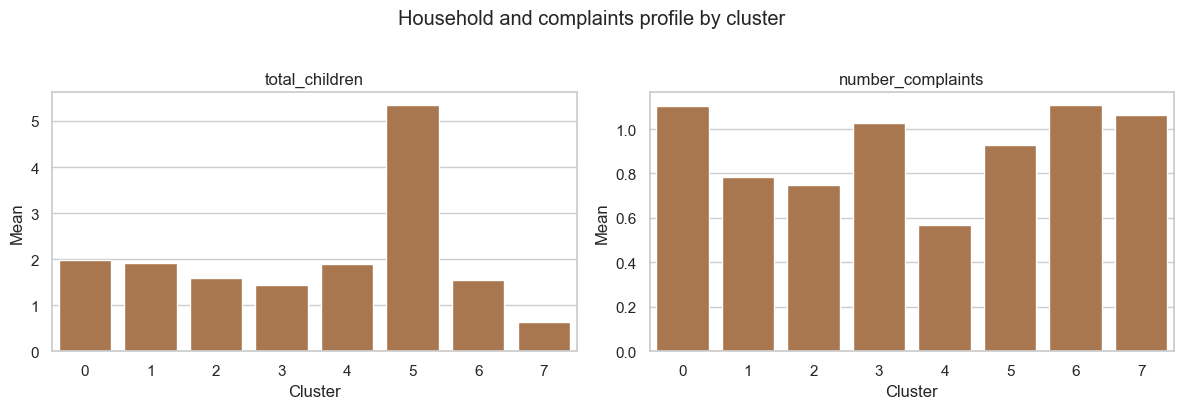

,cluster,total_children,number_complaints
0,0,1.98,1.10
1,1,1.92,0.78
2,2,1.59,0.75
3,3,1.44,1.03
4,4,1.89,0.57
5,5,5.35,0.93
6,6,1.54,1.11
7,7,0.64,1.06


In [10]:
binary_summary, household_summary = ucc.plot_simple_profile_checks(df)

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>6) Normalised comparison</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">Because the variables have different units, a min max scaled comparison is used to identify which clusters are highest or lowest on each feature.</p>
</div>

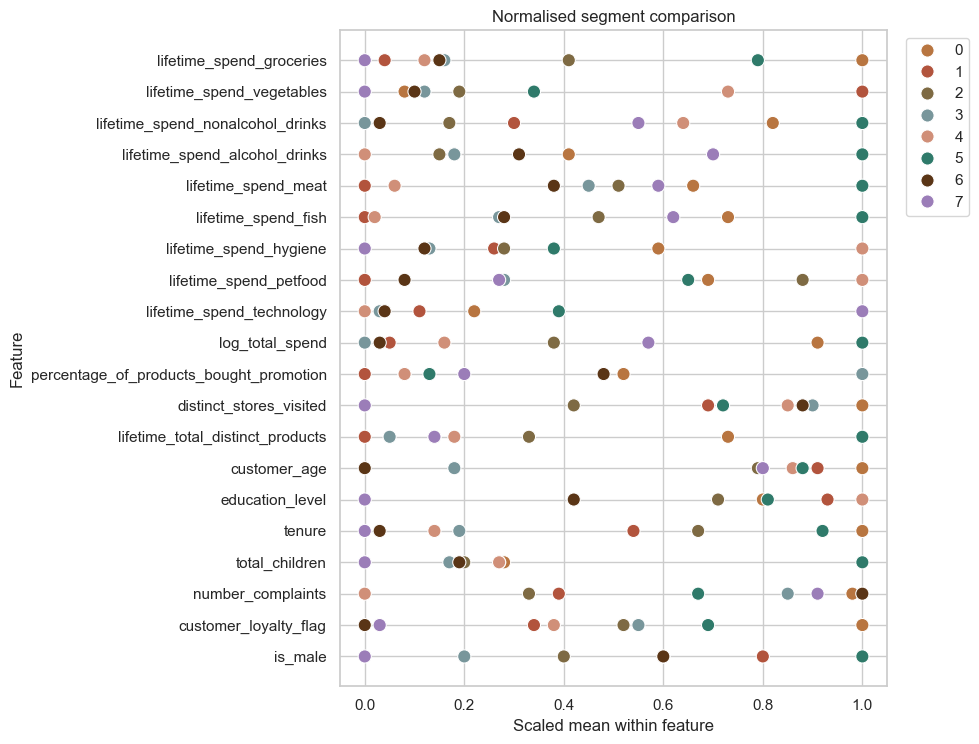

,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_spend_technology,log_total_spend,percentage_of_products_bought_promotion,distinct_stores_visited,lifetime_total_distinct_products,customer_age,education_level,tenure,total_children,number_complaints,customer_loyalty_flag,is_male
cluster,,,,,,,,,,,,,,,,,,,,
0,1.00,0.08,0.82,0.41,0.66,0.73,0.59,0.69,0.22,0.91,0.52,1.00,0.73,1.00,0.80,1.00,0.28,0.98,1.00,0.6
1,0.04,1.00,0.30,0.18,0.00,0.00,0.26,0.00,0.11,0.05,0.00,0.69,0.00,0.91,0.93,0.54,0.27,0.39,0.34,0.8
2,0.41,0.19,0.17,0.15,0.51,0.47,0.28,0.88,0.04,0.38,0.08,0.42,0.33,0.79,0.71,0.67,0.20,0.33,0.52,0.4
3,0.16,0.12,0.00,0.18,0.45,0.27,0.13,0.28,0.03,0.00,1.00,0.90,0.05,0.18,0.42,0.19,0.17,0.85,0.55,0.2
4,0.12,0.73,0.64,0.00,0.06,0.02,1.00,1.00,0.00,0.16,0.08,0.85,0.18,0.86,1.00,0.14,0.27,0.00,0.38,0.6
5,0.79,0.34,1.00,1.00,1.00,1.00,0.38,0.65,0.39,1.00,0.13,0.72,1.00,0.88,0.81,0.92,1.00,0.67,0.69,1.0
6,0.15,0.10,0.03,0.31,0.38,0.28,0.12,0.08,0.04,0.03,0.48,0.88,0.14,0.00,0.42,0.03,0.19,1.00,0.00,0.6
7,0.00,0.00,0.55,0.70,0.59,0.62,0.00,0.27,1.00,0.57,0.20,0.00,0.14,0.80,0.00,0.00,0.00,0.91,0.03,0.0


In [11]:
combined_profile = ucc.profile_table(df, spend_cols + profile_cols)
scaled_profile = ucc.plot_scaled_profile(combined_profile)
display(scaled_profile)

### 6.1 - Radar profile summary

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The radar plots give a compact view of the main profile of each segment. They use the same min max scaled profile as the normalised comparison above, but display one cluster at a time. This makes it easier to see whether a segment has a clear shape, for example promotion driven, technology focused, family oriented or wellness oriented.
<br><br>
Only a limited number of variables is used here so that the circular plots remain readable. The detailed interpretation still comes from the tables and feature by feature plots.
</div>

In [ ]:
radar_features = [
    "lifetime_spend_groceries",
    "lifetime_spend_vegetables",
    "lifetime_spend_hygiene",
    "lifetime_spend_electronics",
    "lifetime_spend_videogames",
    "percentage_of_products_bought_promotion",
    "customer_age",
    "total_children",
    "customer_loyalty_flag",
]

radar_profile = ucc.plot_radar_profiles(
    combined_profile,
    features=radar_features,
    cluster_names=ucc.CLUSTER_NAMES,
    title="Segment radar profiles",
)
display(radar_profile)


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>7) Feature by feature plots</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The barplots and boxplots check whether the differences observed in the profile tables are clear across the distribution or mainly driven by extreme values.</p>
</div>

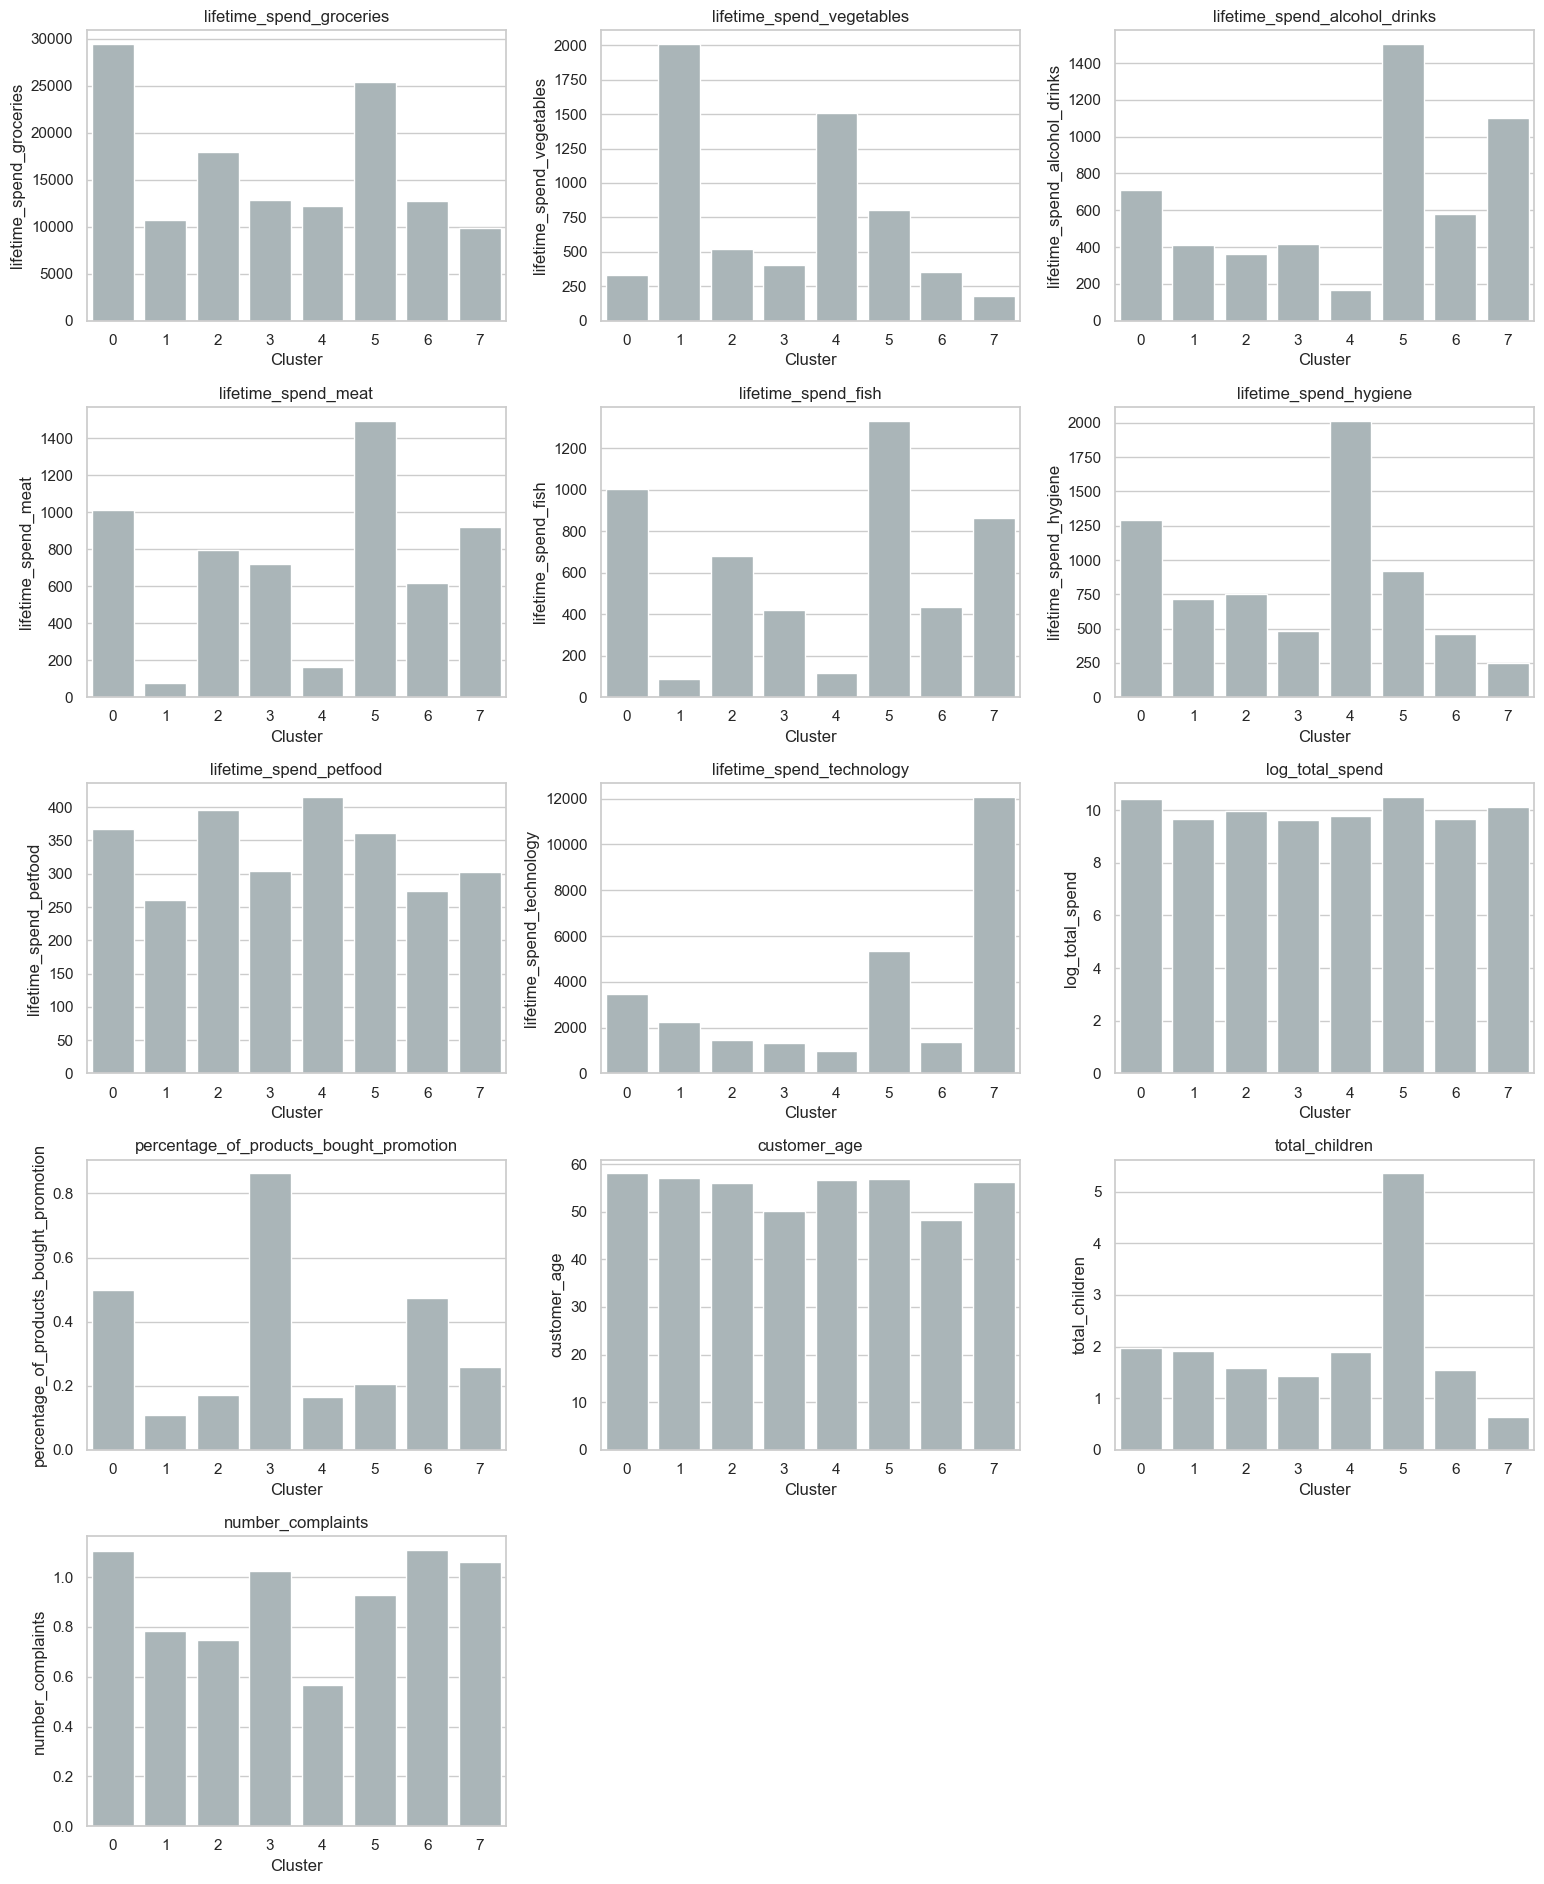

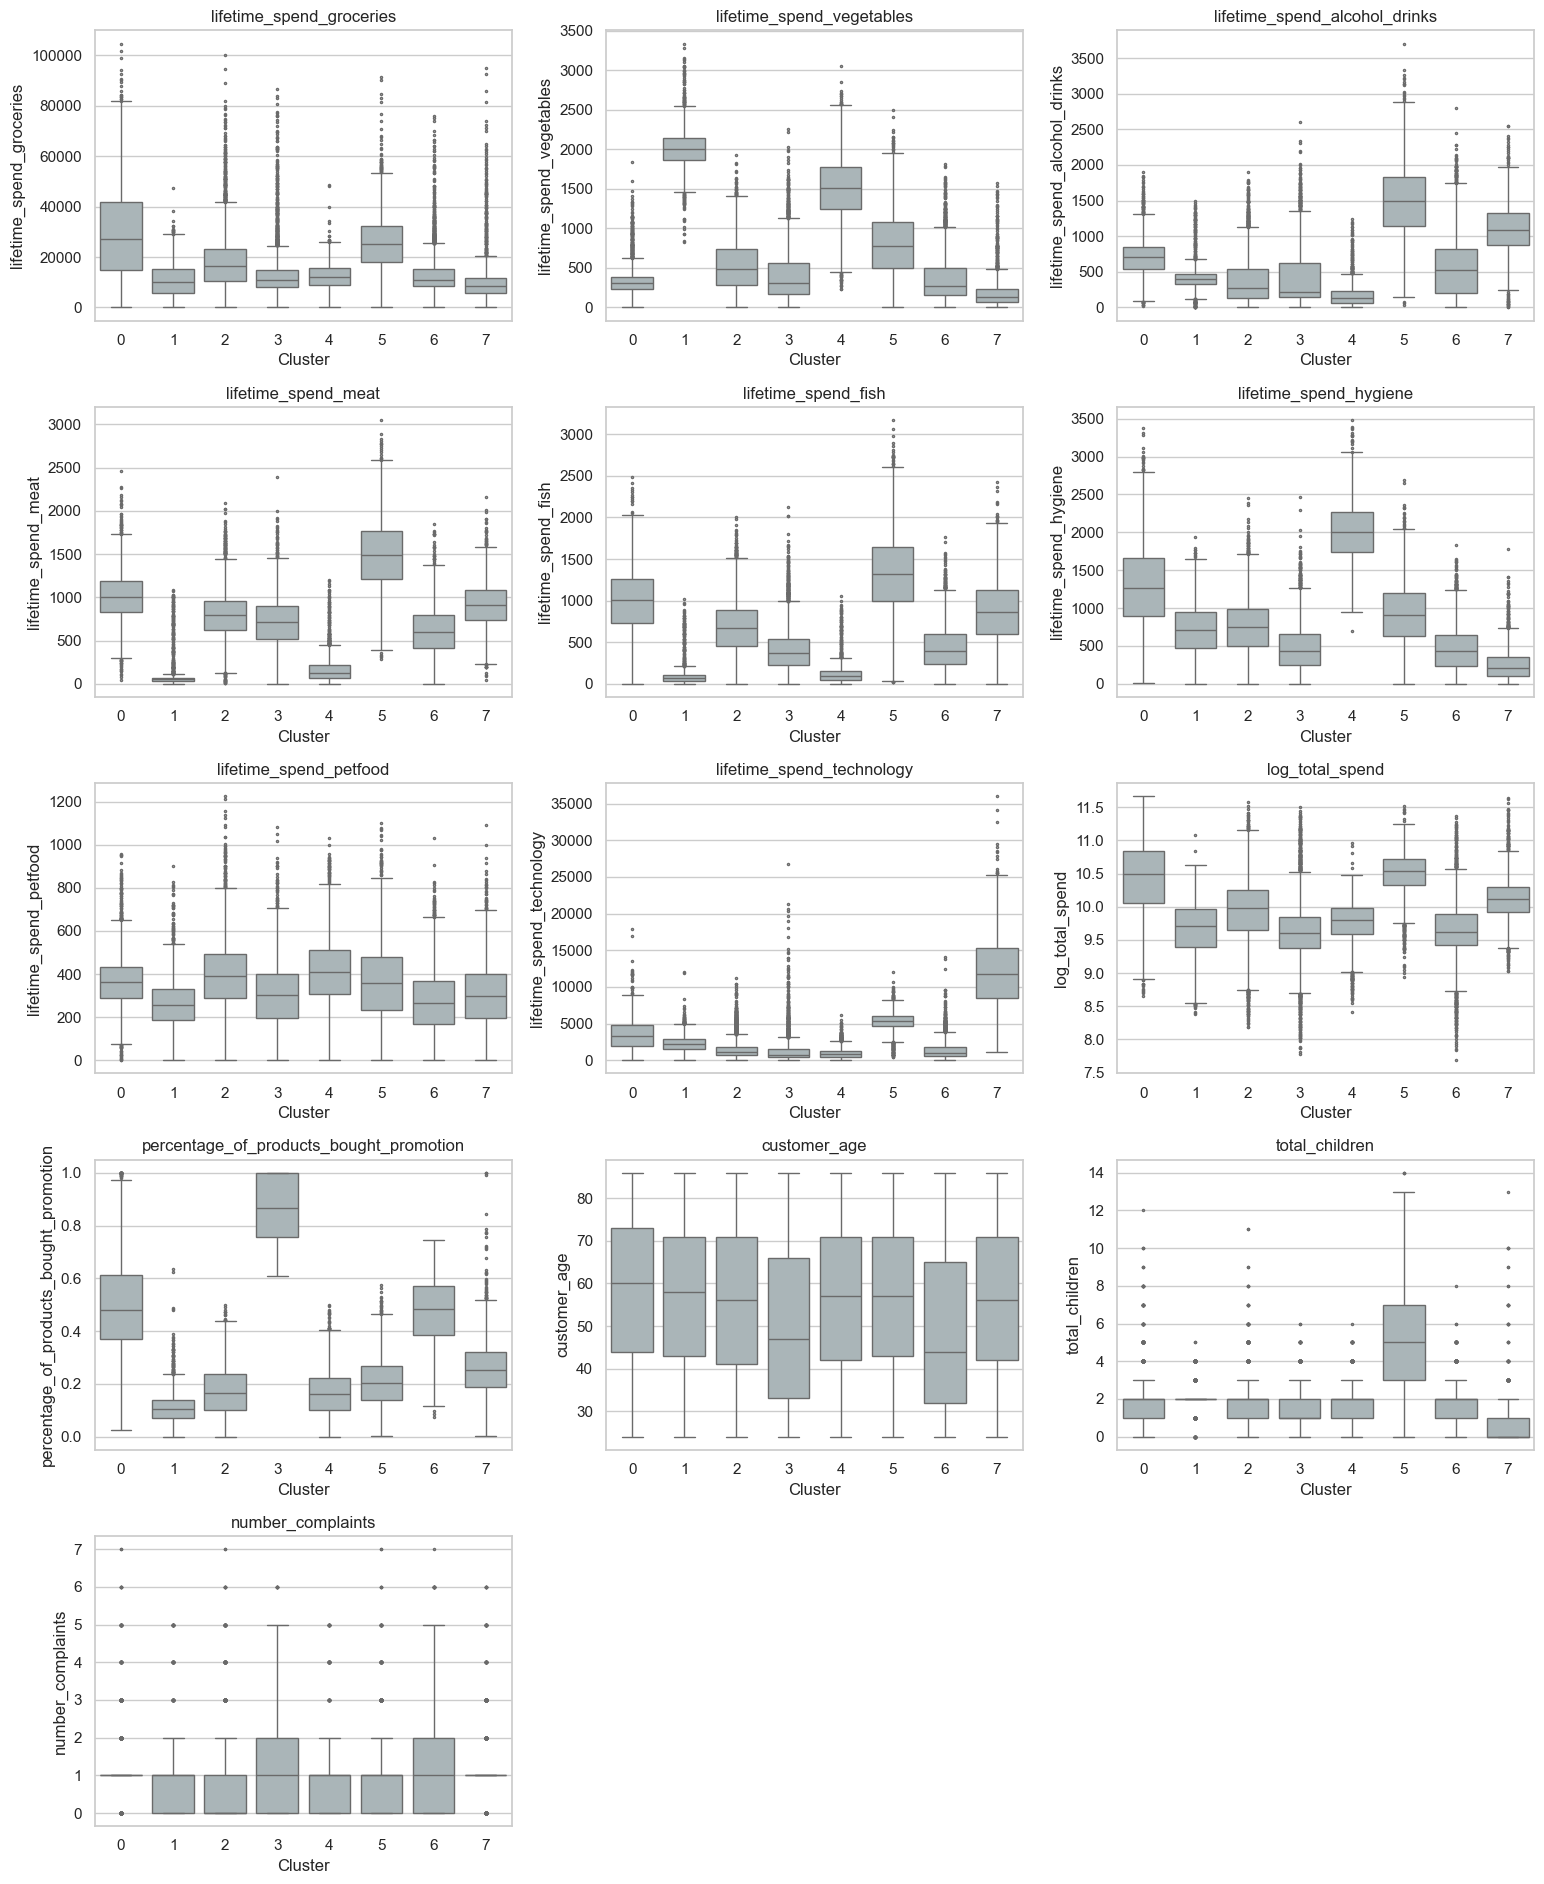

In [13]:
key_plot_cols = ucc.key_plot_columns(df)
ucc.plot_feature_bars(df, key_plot_cols)
ucc.plot_boxplot_grid(df, key_plot_cols)

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>8) Main differentiators by cluster</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The following table lists the largest relative differences from the overall customer base. It is used as a compact evidence table for cluster naming.</p>
</div>

In [14]:
deviations = ucc.top_deviations(combined_profile, n=6)
display(deviations)


,cluster,feature,relative_difference_%,cluster_mean,overall_mean
0,0,lifetime_spend_groceries,80.3,29398.77,16306.23
1,0,lifetime_spend_fish,64.5,1000.67,608.14
2,0,lifetime_total_distinct_products,60.1,238.42,148.91
3,0,lifetime_spend_hygiene,57.3,1290.31,820.44
4,0,lifetime_spend_nonalcohol_drinks,54.3,716.27,464.35
5,0,lifetime_spend_vegetables,-54.0,334.85,727.50
6,1,lifetime_spend_vegetables,175.9,2007.23,727.50
7,1,lifetime_spend_meat,-89.7,74.53,723.79
8,1,lifetime_spend_fish,-85.4,88.95,608.14
9,1,percentage_of_products_bought_promotion,-68.6,0.11,0.35


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>9) Cluster interpretation and naming rationale</b></h2>
<p style="color:#D8C0B4; margin:6px 0 14px 0;">
The final names are assigned after combining the normalised comparison, the deviation table and the original spend profiles. A cluster name is selected only when the same interpretation appears across several variables. This avoids naming a segment from one isolated feature and keeps the labels useful for business discussion.
</p>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>How the final names are chosen.</b><br><br>
The final name of each segment is chosen only when the same pattern appears in more than one view. For example, a customer group is not named after a product category just because one chart is high; the name must also be coherent with the deviation table, the original profile and the broader business interpretation.
</div>

<table style="width:100%; border-collapse:collapse; color:#F3EEE6; font-size:14px;">
<thead>
<tr style="border-bottom:1px solid #D8C0B4;">
<th style="text-align:left; padding:8px;">Cluster</th>
<th style="text-align:left; padding:8px;">Segment name</th>
<th style="text-align:left; padding:8px;">Main evidence</th>
<th style="text-align:left; padding:8px;">Interpretation</th>
</tr>
</thead>
<tbody>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>0</b></td><td style="padding:8px;"><b>Loyalists</b></td><td style="padding:8px;">Highest grocery spend, high tenure, high loyalty rate and the broadest product diversity.</td><td style="padding:8px;">Established high value customers with strong grocery behaviour and long relationship with the retailer.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>1</b></td><td style="padding:8px;"><b>Vegetarians</b></td><td style="padding:8px;">Very high vegetable spend, very low meat and fish spend, and low promotion use.</td><td style="padding:8px;">A clear plant oriented basket profile, defined mainly by what customers buy and avoid.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>2</b></td><td style="padding:8px;"><b>Regulars</b></td><td style="padding:8px;">Largest segment, moderate spend values and no single category dominating the profile.</td><td style="padding:8px;">A broad regular customer group that works as the baseline against more specialised segments.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>3</b></td><td style="padding:8px;"><b>Promoters</b></td><td style="padding:8px;">Highest promotion rate, low spend, lower tenure and low product diversity.</td><td style="padding:8px;">A price sensitive segment where promotional purchases are the strongest behavioural signal.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>4</b></td><td style="padding:8px;"><b>Wellness</b></td><td style="padding:8px;">Highest hygiene spend, high vegetable spend, low meat and fish, and low complaints.</td><td style="padding:8px;">Customers with a health and personal care oriented shopping pattern.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>5</b></td><td style="padding:8px;"><b>Families</b></td><td style="padding:8px;">Highest number of children and very high total spend across several categories.</td><td style="padding:8px;">Large households with broad stock up needs and high basket value.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>6</b></td><td style="padding:8px;"><b>Economizers</b></td><td style="padding:8px;">Younger profile, medium high promotion use, low loyalty and low total spend.</td><td style="padding:8px;">Customers with limited basket value and weaker retailer attachment, but still responsive to promotions.</td></tr>
<tr><td style="padding:8px;"><b>7</b></td><td style="padding:8px;"><b>Techies</b></td><td style="padding:8px;">Highest technology spend, fewest stores visited and very small household size.</td><td style="padding:8px;">Specialised customers dominated by technology and entertainment purchases.</td></tr>
</tbody>
</table>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why there is no final Pets segment.</b><br><br>
A pet oriented alternative was tested in the clustering notebook. It produced a readable pet segment, but the global structure was slightly weaker and the final UMAP was less clean. The final naming therefore keeps petfood as a profiling insight rather than forcing it into the final segmentation. This decision favours a more stable eight cluster solution.
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Segment naming alternatives.</b><br><br>
The names below were considered after comparing the normalised profile, the deviation table and the original spend values. The final name should be short enough to work as a business label, but specific enough to reflect the strongest evidence for each cluster.
<br><br>
<table style="width:100%; border-collapse:collapse; color:#F3EEE6; font-size:14px;">
<thead>
<tr style="border-bottom:1px solid #D8C0B4;">
<th style="text-align:left; padding:8px;">Cluster</th>
<th style="text-align:left; padding:8px;">Preferred name</th>
<th style="text-align:left; padding:8px;">Other possible names</th>
<th style="text-align:left; padding:8px;">Reason for preference</th>
</tr>
</thead>
<tbody>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>0</b></td><td style="padding:8px;">Loyalists</td><td style="padding:8px;">High Value Grocery Shoppers; Loyal Regulars; Grocery Loyalists</td><td style="padding:8px;">Grocery spend, tenure and loyalty are all strong, so the name reflects both value and relationship.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>1</b></td><td style="padding:8px;">Vegetarians</td><td style="padding:8px;">Plant Based Shoppers; Green Shoppers; Vegetable Shoppers</td><td style="padding:8px;">Vegetable spend is high while meat and fish are very low, making the dietary signal clear.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>2</b></td><td style="padding:8px;">Regulars</td><td style="padding:8px;">Routine Shoppers; Core Customers; Regular Shoppers</td><td style="padding:8px;">This is the largest and most balanced group, without one category dominating the profile.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>3</b></td><td style="padding:8px;">Promoters</td><td style="padding:8px;">Deal Seekers; Discount Shoppers; Promo Buyers</td><td style="padding:8px;">Promotion rate is the strongest differentiator and clearly explains the cluster behaviour.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>4</b></td><td style="padding:8px;">Wellness</td><td style="padding:8px;">Health Conscious; Hygiene Focused Shoppers; Mindful Shoppers</td><td style="padding:8px;">Hygiene and vegetables are the clearest positive signals, supported by low meat and fish spend.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>5</b></td><td style="padding:8px;">Families</td><td style="padding:8px;">Extended Households; Family Shoppers; Household Buyers</td><td style="padding:8px;">The children count is the strongest demographic deviation and explains broad high spend.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>6</b></td><td style="padding:8px;">Economizers</td><td style="padding:8px;">Budget Shoppers; Value Shoppers; Price Sensitive Shoppers</td><td style="padding:8px;">The segment combines low value, weaker loyalty and some promotion sensitivity without being the main promotion cluster.</td></tr>
<tr><td style="padding:8px;"><b>7</b></td><td style="padding:8px;">Techies</td><td style="padding:8px;">Technology Specialists; Gadget Buyers; Digital Buyers</td><td style="padding:8px;">Technology spend is by far the strongest single category signal.</td></tr>
</tbody>
</table>
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>10) Geographic check</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">Latitude and longitude are used only for profiling. This plot checks whether any final segment is associated with a specific geographic concentration.</p>
</div>

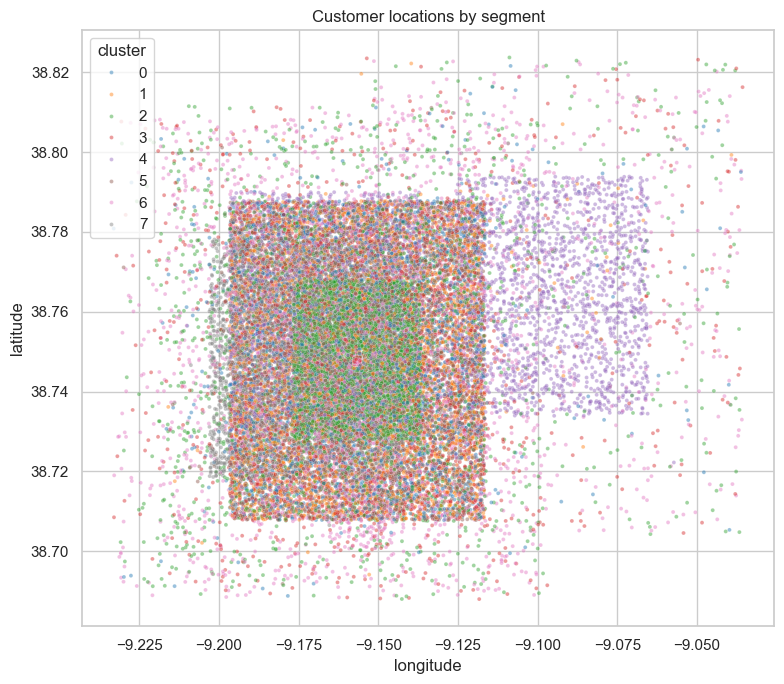

In [15]:
if {"latitude", "longitude"}.issubset(df.columns):
    plt.figure(figsize=(8, 7))
    sns.scatterplot(data=df, x="longitude", y="latitude", hue="cluster", palette="tab10", s=8, alpha=0.45)
    plt.title("Customer locations by segment")
    plt.tight_layout()
    plt.show()


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>11) Final segment names</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The final names are assigned after reviewing the full profile of each cluster. The clustering distance uses selected purchase and promotion variables, while groceries, demographics, loyalty, household structure and complaints support interpretation. Petfood was reviewed during modelling, but it was not strong enough to replace the cleaner final solution.</p>
</div>


In [16]:
display(
    df[["cluster", "cluster_name"]]
    .drop_duplicates()
    .sort_values("cluster")
    .reset_index(drop=True)
)


,cluster,cluster_name
0,0,Loyalists
1,1,Vegetarians
2,2,Regulars
3,3,Promoters
4,4,Wellness
5,5,Families
6,6,Economizers
7,7,Techies


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>12) Export ID and cluster mapping</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The final export keeps one row per customer with the numerical cluster and the corresponding business name. This file is the bridge between the modelling stage and any later business analysis, such as basket analysis or segment based recommendations.</p>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why the mapping is exported.</b><br><br>
The modelling notebook exports numeric cluster labels because they are easier to reproduce and validate. This notebook adds the business names after the characterization step, creating a clean bridge between the technical segmentation and the final business interpretation.
</div>

In [17]:
id_cluster = ucc.export_id_cluster(df, f"{DATA_DIR}/id_and_cluster.csv")
print("Exported rows:", len(id_cluster))
id_cluster.head()


Exported rows: 33038


,customer_id,cluster,cluster_name
0,3,6,Economizers
1,4,4,Wellness
2,5,2,Regulars
3,7,7,Techies
4,8,7,Techies
